<a href="https://colab.research.google.com/github/WVF-1/Pittsburgh-Traffic-Flow/blob/main/traffic_flow_balance_and_desire_lines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pittsburgh Traffic Flow, Part 2: Flow Balance & Desire Lines

**Newsletter series: Geospatial Data & Public Transportation — Project 2 of 5 (EDA, notebook 2)**

Notebook 1 gave us two separate pictures: road hierarchy, and job/worker totals per tract. This notebook connects them and introduces one more mapping technique: **desire lines** — straight lines drawn between origin and destination, weighted by flow volume. It's the standard way transportation planners visualize "who's going where" before worrying about which actual streets they take.

**Two things we'll build:**
1. **Flow balance** — which tracts are "job centers" (way more people commute in than live there) vs. "bedroom communities" (way more residents than local jobs)
2. **Desire lines** — the heaviest home→work commuting flows, drawn as weighted lines on a real map

**Data:** same sources as Notebook 1 — Census LODES (public domain) for flows, OpenStreetMap via `osmnx` (ODbL) re-pulled fresh for spatial context, tract boundaries via `pygris`.

## Setup

In [1]:
!pip install osmnx geopandas contextily pygris -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.9 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import contextily as cx
import requests
import io

ox.settings.log_console = False

FLOW_CMAP = "OrRd"
PGH_BLACK = "#1a1a1a"
DESIRE_LINE_COLOR = "#c1440e"


## Step 1: Upload your Notebook 1 export

Just `pittsburgh_tract_commute_flows.csv` this time.

In [3]:
from google.colab import files

uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))


Saving pittsburgh_road_hierarchy_edges.csv to pittsburgh_road_hierarchy_edges.csv
Saving pittsburgh_tract_commute_flows.csv to pittsburgh_tract_commute_flows.csv
Uploaded: ['pittsburgh_road_hierarchy_edges.csv', 'pittsburgh_tract_commute_flows.csv']


In [4]:
flows = pd.read_csv("pittsburgh_tract_commute_flows.csv", dtype={"GEOID": str})
flows["net_flow"] = flows["jobs_inflow"] - flows["workers_outflow"]

print(f"Tracts: {len(flows)}")
flows.sort_values("net_flow", ascending=False).head()


Tracts: 176


,GEOID,jobs_inflow,workers_outflow,net_flow
45,42003020100,72904.0,1741,71163.0
172,42003982200,19720.0,113,19607.0
91,42003459201,19319.0,2745,16574.0
66,42003421100,13963.0,1859,12104.0
70,42003040200,9388.0,352,9036.0


## Step 2: Job centers vs. bedroom communities

`net_flow > 0` means more people commute *into* that tract for work than live there — a job center. `net_flow < 0` means the opposite — more residents than local jobs, i.e. people who live there mostly work elsewhere. This is the clearest signal in commuting data for "where does traffic actually want to go.

In [5]:
print("Top 5 job centers (net importers of workers):")
print(flows.nlargest(5, "net_flow")[["GEOID", "jobs_inflow", "workers_outflow", "net_flow"]])

print("\nTop 5 bedroom communities (net exporters of workers):")
print(flows.nsmallest(5, "net_flow")[["GEOID", "jobs_inflow", "workers_outflow", "net_flow"]])


Top 5 job centers (net importers of workers):
           GEOID  jobs_inflow  workers_outflow  net_flow
45   42003020100      72904.0             1741   71163.0
172  42003982200      19720.0              113   19607.0
91   42003459201      19319.0             2745   16574.0
66   42003421100      13963.0             1859   12104.0
70   42003040200       9388.0              352    9036.0

Top 5 bedroom communities (net exporters of workers):
           GEOID  jobs_inflow  workers_outflow  net_flow
155  42003484500        444.0             2281   -1837.0
58   42003480400        236.0             2025   -1789.0
107  42003427200        336.0             2006   -1670.0
56   42003290200        212.0             1555   -1343.0
33   42003478200       1044.0             2373   -1329.0


## Step 3: Mapping the imbalance

A diverging colormap centered on zero makes the job-center / bedroom-community split visually obvious — red for net importers, blue for net exporters.

In [6]:
from pygris import tracts

pa_tracts = tracts(state="PA", county="Allegheny", cb=True, year=2022).to_crs("EPSG:4326")[["GEOID", "geometry"]]
place = "Pittsburgh, Pennsylvania, USA"
pgh_boundary = ox.geocode_to_gdf(place)

tract_flow_gdf = pa_tracts.merge(flows, on="GEOID", how="inner")
tract_flow_pgh = gpd.sjoin(tract_flow_gdf, pgh_boundary[["geometry"]], predicate="intersects", how="inner").drop(columns=["index_right"])

print(f"Pittsburgh tracts: {len(tract_flow_pgh)}")


Using FIPS code '42' for input 'PA'
Using FIPS code '003' for input 'Allegheny'
Pittsburgh tracts: 176


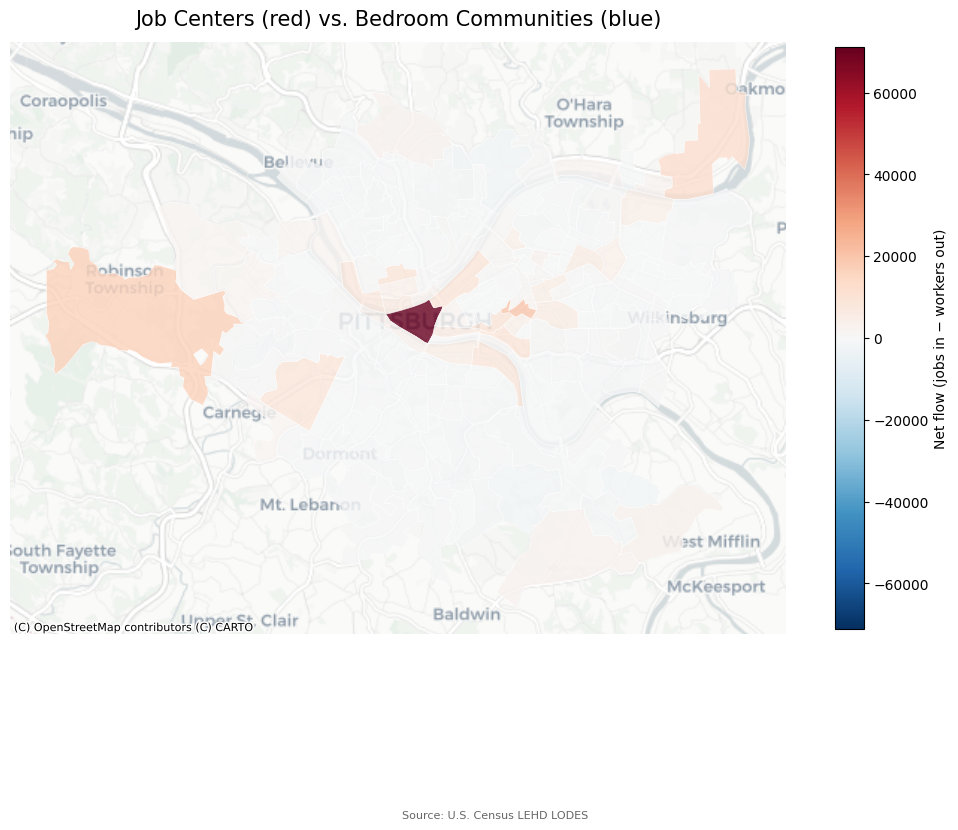

In [7]:
tract_flow_3857 = tract_flow_pgh.to_crs(epsg=3857)

vmax = tract_flow_3857["net_flow"].abs().max()

fig, ax = plt.subplots(figsize=(10, 10))
tract_flow_3857.plot(column="net_flow", cmap="RdBu_r", vmin=-vmax, vmax=vmax, alpha=0.8,
                      edgecolor="white", linewidth=0.4, legend=True, ax=ax,
                      legend_kwds={"label": "Net flow (jobs in − workers out)", "shrink": 0.6})

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_title("Job Centers (red) vs. Bedroom Communities (blue)", fontsize=15, pad=12)
ax.set_axis_off()
fig.text(0.5, 0.02, "Source: U.S. Census LEHD LODES", ha="center", fontsize=8, color="#666")

plt.tight_layout()
plt.savefig("pittsburgh_flow_balance_map.png", dpi=200, bbox_inches="tight")
plt.show()


## Step 4: Desire lines — where the heaviest commutes actually run

This needs pair-level data (home tract → work tract), which we aggregated away in Notebook 1. We re-pull LODES here and keep the tract-pair granularity this time.

In [8]:
LODES_YEAR = 2022  # keep in sync with Notebook 1; check https://lehd.ces.census.gov/data/#lodes for newer years
LODES_URL = f"https://lehd.ces.census.gov/data/lodes/LODES8/pa/od/pa_od_main_JT00_{LODES_YEAR}.csv.gz"

resp = requests.get(LODES_URL)
resp.raise_for_status()
od = pd.read_csv(io.BytesIO(resp.content), compression="gzip", dtype={"w_geocode": str, "h_geocode": str})

ALLEGHENY_FIPS = "42003"
od_allegheny = od[od["w_geocode"].str[:5] == ALLEGHENY_FIPS].copy()
od_allegheny["w_tract"] = od_allegheny["w_geocode"].str[:11]
od_allegheny["h_tract"] = od_allegheny["h_geocode"].str[:11]

# Aggregate to tract-PAIR level (this is the step Notebook 1 skipped)
pair_flows = od_allegheny.groupby(["h_tract", "w_tract"])["S000"].sum().reset_index()
pair_flows = pair_flows.rename(columns={"S000": "flow"})

# Drop within-tract "commutes" (h_tract == w_tract) -- not a meaningful line on a map
pair_flows = pair_flows[pair_flows["h_tract"] != pair_flows["w_tract"]]

print(f"Tract-pair flows: {len(pair_flows):,}")
pair_flows.sort_values("flow", ascending=False).head()


Tract-pair flows: 165,100


,h_tract,w_tract,flow
19935,42003409001,42003020100,429
35514,42003456003,42003020100,397
12201,42003191800,42003020100,360
40740,42003470501,42003020100,342
21569,42003413100,42003020100,342


## Step 5: Build and draw the top desire lines

We only draw the heaviest N pairs — with thousands of tract pairs, drawing all of them just produces an unreadable haze of lines.

In [9]:
TOP_N = 40

top_pairs = pair_flows.nlargest(TOP_N, "flow").copy()

# Centroids in a projected CRS for accuracy, then back to WGS84 for mapping
tracts_proj = pa_tracts.to_crs(epsg=3857)
tracts_proj["centroid"] = tracts_proj.geometry.centroid
centroids = tracts_proj.set_index("GEOID")["centroid"]

top_pairs = top_pairs[top_pairs["h_tract"].isin(centroids.index) & top_pairs["w_tract"].isin(centroids.index)]
top_pairs["h_pt"] = top_pairs["h_tract"].map(centroids)
top_pairs["w_pt"] = top_pairs["w_tract"].map(centroids)

print(f"Drawable top pairs: {len(top_pairs)}")


Drawable top pairs: 39


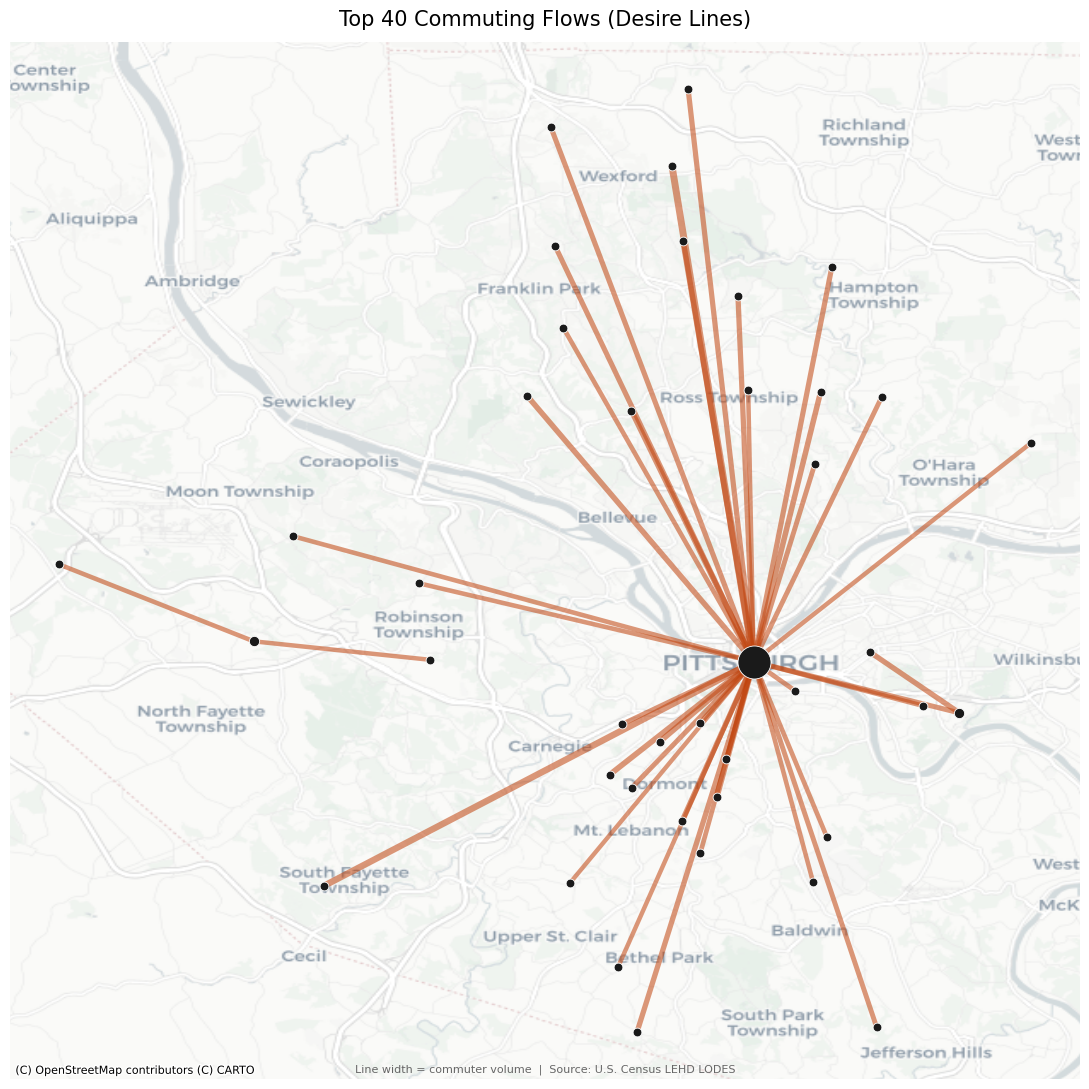

In [10]:
fig, ax = plt.subplots(figsize=(11, 11))

max_flow = top_pairs["flow"].max()

for _, row in top_pairs.iterrows():
    x = [row["h_pt"].x, row["w_pt"].x]
    y = [row["h_pt"].y, row["w_pt"].y]
    lw = 0.5 + 4.5 * (row["flow"] / max_flow)
    ax.plot(x, y, color=DESIRE_LINE_COLOR, linewidth=lw, alpha=0.55, zorder=2, solid_capstyle="round")

# Mark tract centroids that appear as an endpoint, sized by how often they show up
endpoint_counts = pd.concat([top_pairs["h_tract"], top_pairs["w_tract"]]).value_counts()
for geoid, count in endpoint_counts.items():
    pt = centroids[geoid]
    ax.scatter(pt.x, pt.y, s=25 + 15 * count, color=PGH_BLACK, zorder=3, edgecolor="white", linewidth=0.6)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zorder=0)

ax.set_title(f"Top {TOP_N} Commuting Flows (Desire Lines)", fontsize=15, pad=12)
ax.set_axis_off()
fig.text(0.5, 0.02, "Line width = commuter volume  |  Source: U.S. Census LEHD LODES", ha="center", fontsize=8, color="#666")

plt.tight_layout()
plt.savefig("pittsburgh_desire_lines_map.png", dpi=200, bbox_inches="tight")
plt.show()


**A limitation worth naming for readers:** these are straight lines between centroids, not actual routes. Real commuters follow the road network (rivers, bridges, and the hierarchy from Notebook 1 all constrain the real path). Desire lines are a standard *first-pass* way to see volume and direction — Project 4's simulation is where we'll replace this simplification with actual routed paths over the real street graph.

## Step 6: Save exports

In [11]:
top_pairs_export = top_pairs[["h_tract", "w_tract", "flow"]].copy()
top_pairs_export.to_csv("pittsburgh_top_commute_pairs.csv", index=False)

flows.to_csv("pittsburgh_tract_flow_balance.csv", index=False)

print("Saved pittsburgh_top_commute_pairs.csv  --", len(top_pairs_export), "rows")
print("Saved pittsburgh_tract_flow_balance.csv --", len(flows), "rows")


Saved pittsburgh_top_commute_pairs.csv  -- 39 rows
Saved pittsburgh_tract_flow_balance.csv -- 176 rows


In [12]:
from google.colab import files

files.download("pittsburgh_top_commute_pairs.csv")
files.download("pittsburgh_tract_flow_balance.csv")
files.download("pittsburgh_flow_balance_map.png")
files.download("pittsburgh_desire_lines_map.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Recap + what's next

You just:
- Computed a simple but genuinely informative metric — net commuting flow — to distinguish job centers from bedroom communities
- Learned desire lines, a core transportation-planning visualization, and built one with real flow-weighted volume
- Named the honest limitation of straight-line flow (versus actual routed paths)

That's the EDA half of the series done — two projects, four notebooks, all fully open data with no license surprises. **Project 3** picks up here with basic modeling: using road hierarchy and flow patterns as features to predict something concrete (e.g., congestion risk or flow volume by segment), before Project 4 builds the live simulation and Project 5 brings in the GNN.